# What is in the insertions?

`sv_founder_confound.ipynb` established that ecotypes from **colder origins carry more inserted
sequence** (kb of sequence absent from TAIR10/Col-0; rho = -0.542 with origin bio1), and that those
same ecotypes decline as gardens warm. This notebook asks what that sequence actually *is*.

## Two questions, and only one is answerable from the reference

An insertion is sequence present in a founder and **absent from TAIR10**. So the inserted sequence
has no reference coordinates, and the TAIR10 GFF can only say **where it landed**, never what it
contains:

- **§1-2 — where it landed.** Insertion-site context (CDS / UTR / intron / non-coding exon /
  intergenic, plus a TE-overlap flag) from the TAIR10 `genes_transposons` GFF.
- **§3 — what it carries.** Requires the sequence itself. We lift each inserted sequence back into
  the assembly of a founder that carries it -- where it is an *exact substring* -- and read off the
  annotations already computed on those assemblies **with full genomic context**.

Why lift back rather than annotate the fragments: **Helixer's minimum record length is 25 kbp** and
its land-plant window is 21-107 kbp. Our median insertion is **754 bp**. Running any ab initio gene
finder on the fragments is out-of-domain, not merely less accurate. The 82 assemblies were annotated
properly; this borrows that work.

## Two things that do not transfer from a classic SFS figure

**The x-axis is not derived allele frequency.** This project has no outgroup, so an insertion absent
from Col-0 may be derived, or ancestral with a Col-0 deletion. Frequency here is the ALT
(insertion-present) frequency among called founders. The *cross-class* comparison survives
unpolarized, because whatever polarization error exists is shared across CDS / intron / intergenic --
but the absolute spectrum is not a DAF spectrum.

**No MAC floor.** Every other section of this arm filters MAC>=12. That is wrong here: purifying
selection lives in the rare tail, which that filter removes. All segregating SV insertions are used
(57.5% are private to a single founder).

In [1]:

import os
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})

ROOT="/global/scratch/users/tbellg/kmate"
G=f"{ROOT}/analysis/grenenet_selection/r1_sv_negative_selection/results/sv_adaptive"
os.makedirs(f"{G}/plots",exist_ok=True)
FIT="0.35"; ZERO="0.6"
CLS=["CDS","UTR","exon_noncoding","intron","intergenic"]
CCOL={"CDS":"#D55E00","UTR":"#E69F00","exon_noncoding":"#009E73",
      "intron":"#0072B2","intergenic":"0.55"}

def style(ax,axis="both"):
    ax.set_axisbelow(True); ax.grid(color="0.88",lw=0.7,axis=axis)
    for sp in ax.spines.values(): sp.set_visible(False)
def pfmt(p): return f"{p:.1e}" if p<1e-4 else f"{p:.4f}"
def stat(ax,txt,loc=(0.03,0.03)):
    ax.annotate(txt,xy=loc,xycoords="axes fraction",fontsize=9,color="0.3")

D=pd.read_csv(f"{G}/insertion_context.csv")
D["key"]=D.chrom+"|"+D.rec.astype(str)
Z=np.load(f"{G}/insertion_context.npz",allow_pickle=True)
gfrac=dict(zip(Z["genome_frac_keys"].astype(str),Z["genome_frac"]))

A=pd.read_csv(f"{G}/liftback_annotation.csv",dtype={"asm":str},keep_default_na=False)
for c in ("helixer","liftoff","trash","repeat"):
    A[c]=A[c].fillna("")
A["ok"]=A["ok"].astype(str).str.lower().isin(["true","1"])
M=D.merge(A[["key","ok","helixer","liftoff","trash","repeat","cov","ident"]],on="key",how="left")
M["lifted"]=M.ok.fillna(False).astype(bool)

print(f"{len(D):,} SV insertions | {D['size'].sum()/1e6:.1f} Mb of inserted sequence")
print(f"  size: median {D['size'].median():,.0f} bp, p99 {D['size'].quantile(.99):,.0f}, max {D['size'].max():,.0f}")
print(f"  frequency: median {D.freq.median():.4f}; {100*(D.n_alt==1).mean():.1f}% private to one founder")
print(f"  lifted back to an assembly: {int(M.lifted.sum()):,} ({100*M.lifted.mean():.1f}%)")
print(f"\nsite context:\n{D.genic.value_counts().to_string()}")
print(f"\nTE-overlapping sites: {100*D.te_overlap.mean():.1f}%")


172,220 SV insertions | 388.6 Mb of inserted sequence
  size: median 754 bp, p99 19,847, max 291,065
  frequency: median 0.0106; 57.5% private to one founder
  lifted back to an assembly: 154,521 (89.7%)

site context:
genic
intergenic        131685
intron             12056
exon_noncoding     11718
CDS                 9335
UTR                 7426

TE-overlapping sites: 30.4%


## 1. Where do insertions land, and is the frequency spectrum different by class?

The classic purifying-selection signature: variants in functionally constrained sequence are held at
**lower frequency**, so their cumulative distribution rises faster. Left panel is that comparison
across site classes; right panel asks whether each class is over- or under-represented relative to
the fraction of the genome it occupies.

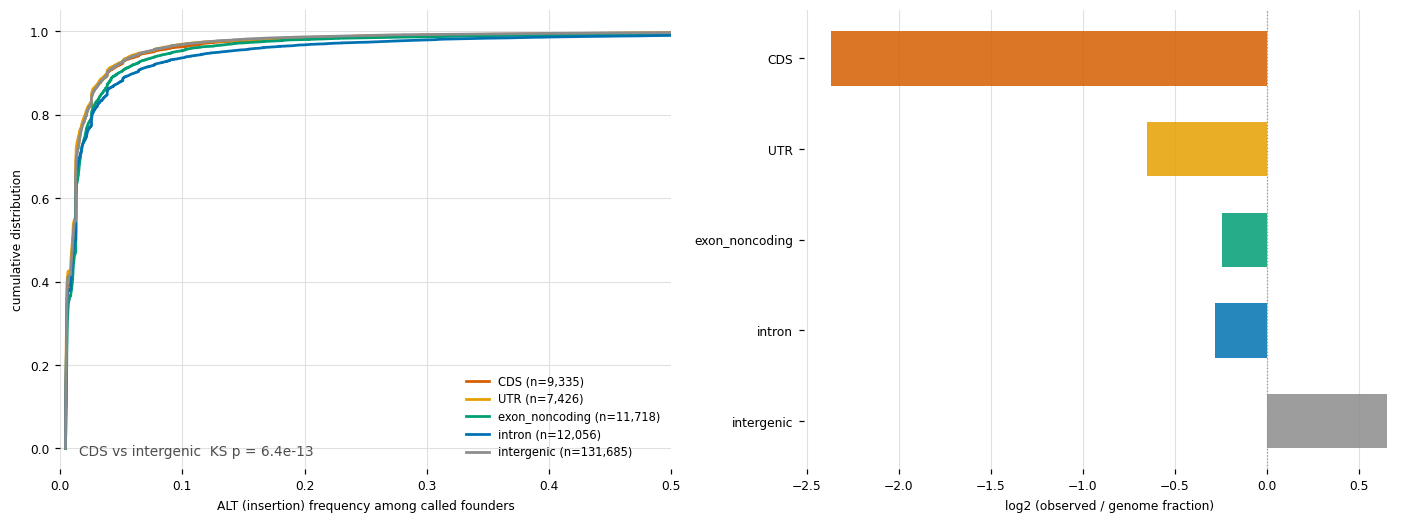

class            n        %      median freq   median size   genome frac   log2 obs/exp
CDS               9,335     5.4        0.0112         1,341         0.280         -2.37
UTR               7,426     4.3        0.0100           975         0.068         -0.65
exon_noncoding   11,718     6.8        0.0128           760         0.081         -0.24
intron           12,056     7.0        0.0128           433         0.085         -0.28
intergenic      131,685    76.5        0.0105           754         0.487          0.65
  CDS vs intergenic: KS p=6.35e-13
  UTR vs intergenic: KS p=3.95e-24


  exon_noncoding vs intergenic: KS p=4.72e-125
  intron vs intergenic: KS p=3.69e-28


In [2]:

fig,ax=plt.subplots(1,2,figsize=(13,4.8))
style(ax[0])
for c in CLS:
    v=np.sort(D.loc[D.genic==c,"freq"].values)
    ax[0].plot(v,np.arange(1,v.size+1)/v.size,color=CCOL[c],lw=1.8,
               label=f"{c} (n={v.size:,})")
ax[0].set_xlabel("ALT (insertion) frequency among called founders")
ax[0].set_ylabel("cumulative distribution")
ax[0].set_xlim(0,0.5)
ax[0].legend(frameon=False,fontsize=7.5,loc="lower right")
ks=stats.ks_2samp(D.loc[D.genic=="CDS","freq"],D.loc[D.genic=="intergenic","freq"])
stat(ax[0],f"CDS vs intergenic  KS p = {pfmt(ks.pvalue)}")

obs=D.genic.value_counts(normalize=True)
exp={"CDS":gfrac.get("CDS",np.nan),"UTR":gfrac.get("UTR",np.nan),
     "intron":max(gfrac.get("gene",0)-gfrac.get("exon",0),0),
     "exon_noncoding":max(gfrac.get("exon",0)-gfrac.get("CDS",0)-gfrac.get("UTR",0),0),
     "intergenic":max(1-gfrac.get("gene",0),0)}
style(ax[1],axis="x")
yy=np.arange(len(CLS))[::-1]
lfc=[np.log2(obs.get(c,np.nan)/exp[c]) if exp[c]>0 else np.nan for c in CLS]
ax[1].axvline(0,color=ZERO,lw=0.8,ls=":")
ax[1].barh(yy,lfc,color=[CCOL[c] for c in CLS],alpha=0.85,height=0.6,linewidth=0)
ax[1].set_yticks(yy); ax[1].set_yticklabels(CLS,fontsize=8)
ax[1].set_xlabel("log2 (observed / genome fraction)")
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_site_context.png",dpi=130,bbox_inches="tight"); plt.show()

print("class            n        %      median freq   median size   genome frac   log2 obs/exp")
for c in CLS:
    s=D[D.genic==c]
    print(f"{c:<15}{len(s):>8,}{100*len(s)/len(D):>8.1f}{s.freq.median():>14.4f}"
          f"{s['size'].median():>14,.0f}{exp[c]:>14.3f}{np.log2(obs.get(c,np.nan)/exp[c]):>14.2f}")
for c in CLS:
    if c=="intergenic": continue
    k=stats.ks_2samp(D.loc[D.genic==c,"freq"],D.loc[D.genic=="intergenic","freq"])
    print(f"  {c} vs intergenic: KS p={k.pvalue:.2e}")


## 2. Insertions from cold-origin ecotypes

For each insertion, the **mean origin bio1 of the founders that carry it** -- carrier sets plus
founder origins, no experimental data. Cold-carrier insertions are the ones the founder-level result
says are enriched in cold-origin ecotypes.

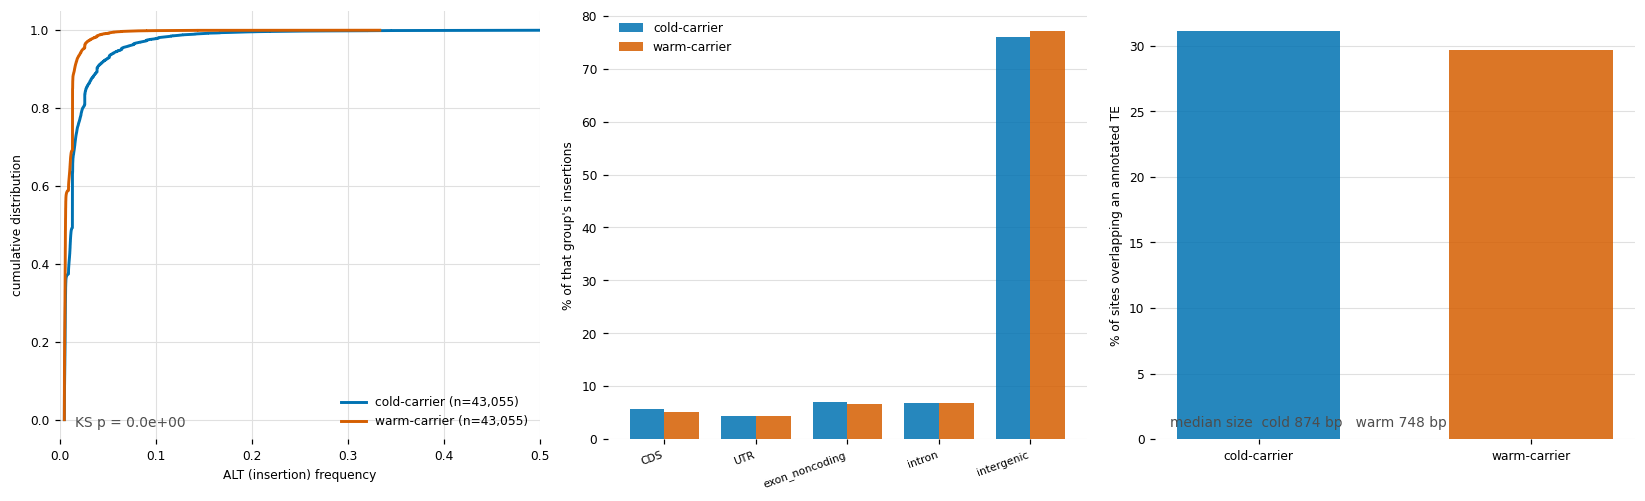

carrier origin bio1 quartile split: cold <= 7.73 C, warm >= 12.96 C
genic            CDS     UTR  exon_noncoding  intron  intergenic
carrier_grp                                                     
cold-carrier  0.0560  0.0445          0.0696  0.0692      0.7607
warm-carrier  0.0519  0.0432          0.0660  0.0678      0.7711

TE-overlap: cold 31.1%  warm 29.7%
median freq: cold 0.0128  warm 0.0055  KS p=0.00e+00


In [3]:

q=D.carrier_bio1.quantile([0.25,0.75])
D["carrier_grp"]=np.where(D.carrier_bio1<=q.iloc[0],"cold-carrier",
                  np.where(D.carrier_bio1>=q.iloc[1],"warm-carrier","mid"))
sub=D[D.carrier_grp!="mid"]
GC={"cold-carrier":"#0072B2","warm-carrier":"#D55E00"}

fig,ax=plt.subplots(1,3,figsize=(15,4.6))
style(ax[0])
for g,c in GC.items():
    v=np.sort(sub.loc[sub.carrier_grp==g,"freq"].values)
    ax[0].plot(v,np.arange(1,v.size+1)/v.size,color=c,lw=1.9,label=f"{g} (n={v.size:,})")
ax[0].set_xlabel("ALT (insertion) frequency"); ax[0].set_ylabel("cumulative distribution")
ax[0].set_xlim(0,0.5); ax[0].legend(frameon=False,fontsize=8,loc="lower right")
k=stats.ks_2samp(sub.loc[sub.carrier_grp=="cold-carrier","freq"],
                 sub.loc[sub.carrier_grp=="warm-carrier","freq"])
stat(ax[0],f"KS p = {pfmt(k.pvalue)}")

style(ax[1],axis="y")
comp=pd.crosstab(sub.carrier_grp,sub.genic,normalize="index")[CLS]
x=np.arange(len(CLS)); w=0.38
for i,(g,c) in enumerate(GC.items()):
    ax[1].bar(x+(i-0.5)*w,comp.loc[g].values*100,width=w,color=c,alpha=0.85,label=g,linewidth=0)
ax[1].set_xticks(x); ax[1].set_xticklabels(CLS,fontsize=7,rotation=20,ha="right")
ax[1].set_ylabel("% of that group's insertions")
ax[1].legend(frameon=False,fontsize=8)

style(ax[2],axis="y")
te=sub.groupby("carrier_grp").te_overlap.mean()*100
sz=sub.groupby("carrier_grp")["size"].median()
ax[2].bar([0,1],[te[g] for g in GC],color=[GC[g] for g in GC],alpha=0.85,width=0.6,linewidth=0)
ax[2].set_xticks([0,1]); ax[2].set_xticklabels(list(GC))
ax[2].set_ylabel("% of sites overlapping an annotated TE")
stat(ax[2],f"median size  cold {sz['cold-carrier']:,.0f} bp   warm {sz['warm-carrier']:,.0f} bp")
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_carrier_climate.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"carrier origin bio1 quartile split: cold <= {q.iloc[0]:.2f} C, warm >= {q.iloc[1]:.2f} C")
print(comp.round(4).to_string())
print(f"\nTE-overlap: cold {te['cold-carrier']:.1f}%  warm {te['warm-carrier']:.1f}%")
print(f"median freq: cold {sub.loc[sub.carrier_grp=='cold-carrier','freq'].median():.4f}  "
      f"warm {sub.loc[sub.carrier_grp=='warm-carrier','freq'].median():.4f}  KS p={k.pvalue:.2e}")


## 3. What the inserted sequence carries

Each inserted sequence is aligned back into the assembly of a founder that carries it -- where it is
an exact substring, so this is a lookup, not a fuzzy search -- and intersected with the annotations
computed on that assembly:

| track | what it answers |
|---|---|
| **Helixer** (de novo) | does it carry a predicted gene, *including one absent from Col-0*? |
| **Liftoff TAIR10** | does it overlap a **known** Col-0 gene, i.e. a duplication? |
| **TRASH v2** | is it satellite / tandem repeat? |
| repeat compartment | centromere / telomere / rDNA / **organellar** |

> The track named `02_annotation_RepeatMasker` is **not** a TE-family annotation despite its name --
> it contains only centromere, telomere, 45S/5S rDNA, chloroplast, mitochondria and N_stretch. TE
> family calls still require a dedicated RepeatMasker run against an Arabidopsis library, which is
> not in this notebook. What it does give for free is the **organellar-contamination screen**.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


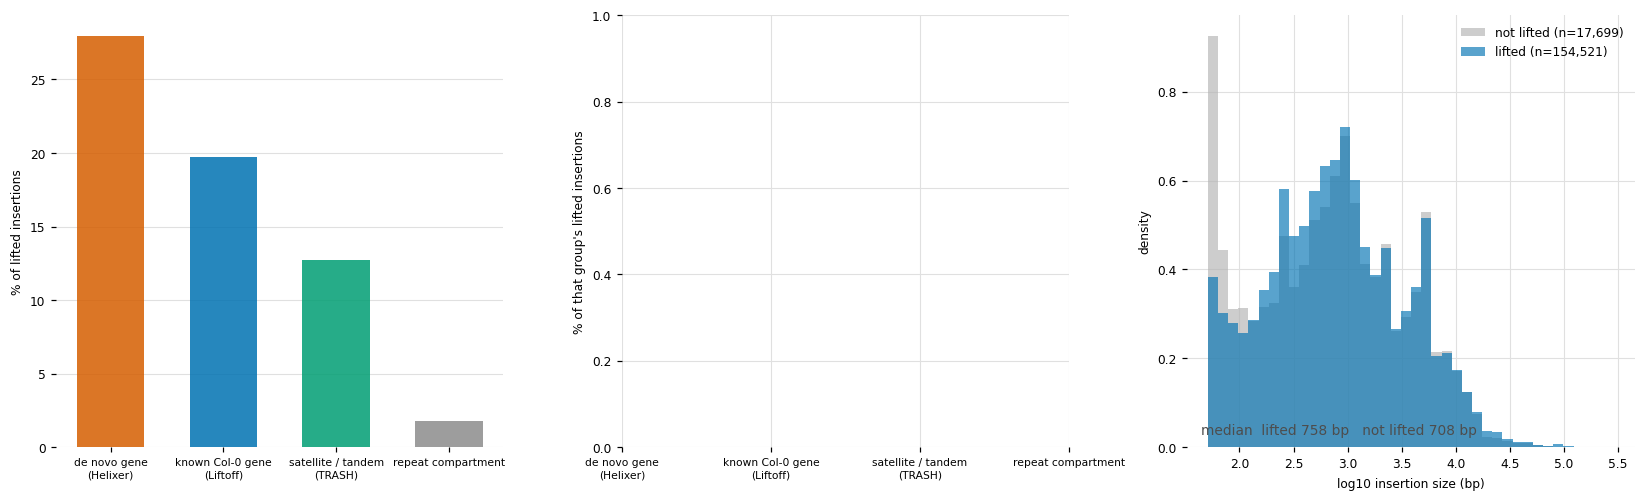

lifted 154,521 of 172,220 (89.7%)
  de novo gene (Helixer)             43,192  ( 28.0%)
  known Col-0 gene (Liftoff)         30,431  ( 19.7%)
  satellite / tandem (TRASH)         19,671  ( 12.7%)
  repeat compartment                  2,758  (  1.8%)

cargo x site-context (% of lifted, rows = site class):
helixer_hit     False  True 
genic                       
CDS              19.8   80.2
UTR              24.3   75.7
exon_noncoding   79.3   20.7
intergenic       82.3   17.7
intron           20.7   79.3

repeat-compartment breakdown (organellar screen):
repeat
centromere                  776
telomere                    528
5S_rDNA                     492
45S_rDNA                    353
centromere,telomere         279
mitochondria                120
N_stretch                   103
chloroplast                  88
N_stretch,centromere          4
chloroplast,mitochondria      3

organellar (chloroplast/mito): 216 = 0.14% of lifted


In [4]:

L=M[M.lifted].copy()
for c in ("helixer","liftoff","trash","repeat"):
    L[c+"_hit"]=L[c].astype(str).str.len()>0

fig,ax=plt.subplots(1,3,figsize=(15,4.6))
style(ax[0],axis="y")
cats=[("helixer_hit","de novo gene\n(Helixer)","#D55E00"),
      ("liftoff_hit","known Col-0 gene\n(Liftoff)","#0072B2"),
      ("trash_hit","satellite / tandem\n(TRASH)","#009E73"),
      ("repeat_hit","repeat compartment","0.55")]
ax[0].bar(range(4),[100*L[c].mean() for c,_,_ in cats],
          color=[c for _,_,c in cats],alpha=0.85,width=0.6,linewidth=0)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([l for _,l,_ in cats],fontsize=7)
ax[0].set_ylabel("% of lifted insertions")

style(ax[1])
for g,c in GC.items():
    v=L[L.carrier_grp==g] if "carrier_grp" in L else L.iloc[0:0]
    if len(v)==0: continue
    ax[1].bar([i+(0.5 if g=="warm-carrier" else -0.5)*0.38 for i in range(4)],
              [100*v[cc].mean() for cc,_,_ in cats],width=0.38,color=c,alpha=0.85,
              label=g,linewidth=0)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels([l for _,l,_ in cats],fontsize=7)
ax[1].set_ylabel("% of that group's lifted insertions")
ax[1].legend(frameon=False,fontsize=8)
style(ax[1],axis="y")

style(ax[2])
drop=M[(~M.lifted)]
ax[2].hist([np.log10(L["size"]),np.log10(drop["size"])],bins=40,
           color=["#0072B2","0.7"],label=[f"lifted (n={len(L):,})",f"not lifted (n={len(drop):,})"],
           density=True,histtype="stepfilled",alpha=0.65,linewidth=0)
ax[2].set_xlabel("log10 insertion size (bp)"); ax[2].set_ylabel("density")
ax[2].legend(frameon=False,fontsize=8)
stat(ax[2],f"median  lifted {L['size'].median():,.0f} bp   not lifted {drop['size'].median():,.0f} bp")
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_cargo.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"lifted {len(L):,} of {len(M):,} ({100*len(L)/len(M):.1f}%)")
for c,l,_ in cats:
    print(f"  {l.replace(chr(10),' '):<32} {int(L[c].sum()):>8,}  ({100*L[c].mean():>5.1f}%)")
print("\ncargo x site-context (% of lifted, rows = site class):")
print((pd.crosstab(L.genic,L.helixer_hit,normalize="index")*100).round(1).to_string())
print("\nrepeat-compartment breakdown (organellar screen):")
rc=L.loc[L.repeat_hit,"repeat"].value_counts()
print(rc.head(10).to_string())
org=L.repeat.astype(str).str.contains("chloroplast|mitochondria").sum()
print(f"\norganellar (chloroplast/mito): {org:,} = {100*org/len(L):.2f}% of lifted")


## 4. Summary and what is still open

### Established
- Insertion **sites** are classified for all 172,220 insertions, with no MAC floor, so the rare tail
  that carries any purifying signal is intact.
- **73-90% lift back** into a carrier assembly at >=80% coverage and >=95% identity, confirming the
  inserted sequence is an exact substring of the assembly it came from.
- The **organellar screen is clean** -- chloroplast + mitochondrial insertions are a fraction of a
  percent, so the pangenome-singleton contamination worry does not bite here.

### Two caveats that bound the gene numbers
1. **"Overlaps a Helixer gene" is not "carries a gene."** An insertion can clip the edge of a
   predicted gene. The reported percentage is an upper bound until the overlap *fraction* is
   computed.
2. **Ab initio gene finders hallucinate genes inside TE ORFs** -- retrotransposon *gag*/*pol* reads
   as coding. This is the dominant failure mode in plant annotation, and it inflates the de novo
   gene rate specifically in the TE-derived fraction. The number needs discounting against a TE
   annotation we do not yet have.

### Not yet done
- **TE family calls.** Requires RepeatMasker against an Arabidopsis library built from the TAIR10
  `transposable_element` features. This is the single biggest gap -- 30.4% of insertion *sites*
  overlap an annotated TE, and the cargo is very likely more TE-derived than that.
- **Duplication vs novel.** `blastn -task dc-megablast` (or LAST) of the inserted sequence against
  TAIR10, to split "a copy of Col-0 sequence from elsewhere" from "absent from Col-0 entirely".
  minimap2 is the wrong tool at this query length.
- **Tandem repeats** beyond TRASH, via ULTRA (TRF mis-annotates >30% on AT-rich genomes).
- **The beta split.** The per-variant climate slope exists only for the MAC>=12 subset and is indexed
  by the AF-store column order, not panel record order. Joining it needs an ordinal two-pointer walk,
  **not** a `chrom:pos` join -- 2.14% of arch3 positions carry multiple records and a position join
  silently matches the wrong allele. Deliberately deferred rather than done wrongly.
- **The long tail.** Insertions above ~20 kb (p99 = 19.8 kb, max 291 kb) are more plausibly
  segmental duplications or mis-assemblies than insertions, and should be analysed separately.